# Sparse Readout-Error Mitigation — end-to-end demo

A self-contained demonstration of the sparse readout-error mitigation (REM)
implemented in [`sparse_rem.py`](sparse_rem.py). The method builds a reduced
transition matrix over only the *observed* bitstrings (Nation et al.,
[PRX Quantum 2, 040326 (2021)](https://doi.org/10.1103/PRXQuantum.2.040326)).

`mitigate_readout_errors(circuit, backend)` wraps a Qiskit circuit: it
calibrates per-qubit confusion matrices, runs the circuit, and
returns the raw and readout-mitigated probability distributions.

Dependencies: `qiskit`, `qiskit-aer`, `qiskit-ibm-runtime` (fake backends only),
`numpy`, `scipy`, `matplotlib`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit.quantum_info import hellinger_fidelity

from sparse_rem import mitigate_readout_errors

SHOTS = 20_000
noisy_backend = AerSimulator.from_backend(FakeManilaV2())
ideal_backend = AerSimulator()

## Helpers

`ideal_probs` gives the noise-free reference distribution; `report` prints the
Hellinger fidelity to that reference before and after mitigation; `plot_comparison`
draws ideal / noisy / mitigated side by side.

In [2]:
def ideal_probs(circuit):
    counts = ideal_backend.run(circuit, shots=SHOTS).result().get_counts()
    counts = {s.replace(" ", ""): c for s, c in counts.items()}
    total = sum(counts.values())
    return {s: c / total for s, c in counts.items()}


def report(ideal, out, label):
    f_noisy = hellinger_fidelity(ideal, out["raw"])
    f_mit = hellinger_fidelity(ideal, out["mitigated"])
    print(f"{label}")
    print(f"  measured physical qubits: {out['measured_physical_qubits']}")
    print(f"  Hellinger fidelity  noisy={f_noisy:.4f}  mitigated={f_mit:.4f}"
          f"  (improvement {f_mit - f_noisy:+.4f})")
    return f_noisy, f_mit


SERIES = {"Ideal": "#2a78d6", "Noisy": "#eb6834", "Mitigated": "#1baf7a"}


def plot_comparison(ideal, out, title, top=8):
    dists = [ideal, out["raw"], out["mitigated"]]
    states = sorted(set().union(*dists), key=lambda s: -ideal.get(s, 0))[:top]
    x = np.arange(len(states))
    width = 0.27

    fig, ax = plt.subplots(figsize=(max(6, len(states) * 0.95), 4.2))
    for i, (name, color) in enumerate(SERIES.items()):
        ax.bar(x + (i - 1) * width, [dists[i].get(s, 0) for s in states],
               width, label=name, color=color, zorder=3)

    ax.set_xticks(x)
    ax.set_xticklabels(states, fontfamily="monospace")
    ax.set_ylabel("probability")
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", color="#e6e6e6", zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False, ncols=3, loc="upper right")
    fig.tight_layout()
    plt.show()

## Example 1: GHZ state, all qubits measured

A 4-qubit GHZ state should yield only `0000` and `1111`. Readout noise leaks
weight into neighbouring strings; mitigation restores the bimodal distribution.

GHZ (4 qubits, full measurement)
  measured physical qubits: [0, 1, 2, 3]
  Hellinger fidelity  noisy=0.8286  mitigated=0.9836  (improvement +0.1550)


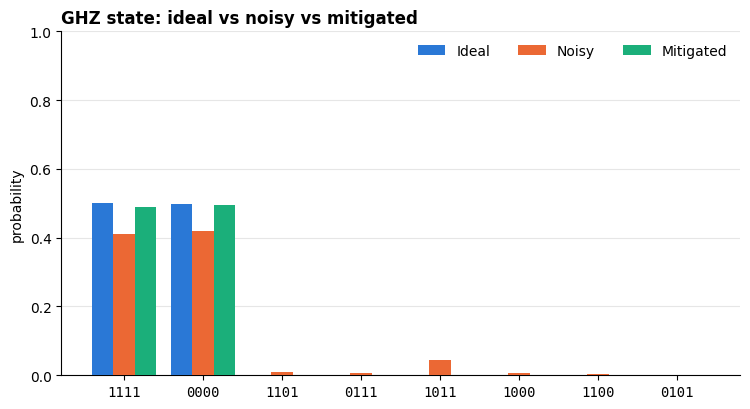

In [3]:
n = 4
ghz = QuantumCircuit(n)
ghz.h(0)
for q in range(n - 1):
    ghz.cx(q, q + 1)
ghz.measure_all()

ghz_ideal = ideal_probs(ghz)
ghz_out = mitigate_readout_errors(ghz, noisy_backend, shots=SHOTS, local=True, matrix_format="auto")

report(ghz_ideal, ghz_out, "GHZ (4 qubits, full measurement)")
plot_comparison(ghz_ideal, ghz_out, "GHZ state: ideal vs noisy vs mitigated")

## Example 2: partial measurement (a strict subset of qubits)

Sampler-mode workloads (e.g. amplitude estimation) often measure only part of
the register. Here a 4-qubit circuit prepares `|1>` on three qubits and measures
only those three into a 3-bit register; the fourth qubit is left unmeasured. The
mitigator must drive the confusion-matrix reduction by the *measured* qubits, so
the result stays a 3-bit distribution peaked at `111`.

Partial measurement (3 of 4 qubits)
  measured physical qubits: [0, 1, 2]
  Hellinger fidelity  noisy=0.8523  mitigated=0.9996  (improvement +0.1473)


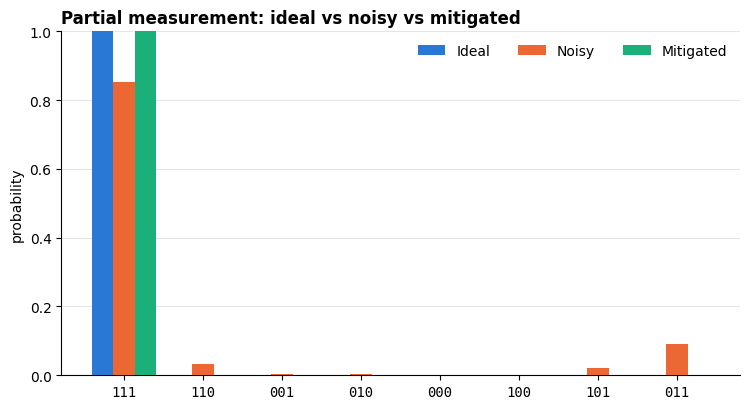

In [4]:
num_measured = 3
qreg = QuantumRegister(4, "q")
creg = ClassicalRegister(num_measured, "c")
partial = QuantumCircuit(qreg, creg)
for q in range(num_measured):
    partial.x(q)
partial.measure(range(num_measured), range(num_measured))

partial_ideal = ideal_probs(partial)
partial_out = mitigate_readout_errors(partial, noisy_backend, shots=SHOTS, local=True, matrix_format="auto")

report(partial_ideal, partial_out, "Partial measurement (3 of 4 qubits)")
assert all(len(s) == num_measured for s in partial_out["mitigated"])
assert max(partial_out["mitigated"], key=partial_out["mitigated"].get) == "1" * num_measured
plot_comparison(partial_ideal, partial_out, "Partial measurement: ideal vs noisy vs mitigated")

## Example 3: dense vs sparse solver agree

The `matrix_format` switch selects the dense exact solver or the sparse
iterative (LGMRES) solver. On the same circuit both recover essentially the same
distribution and both improve on the raw fidelity.

dense solver
  measured physical qubits: [0, 1, 2, 3]
  Hellinger fidelity  noisy=0.8224  mitigated=0.9793  (improvement +0.1569)
sparse solver
  measured physical qubits: [0, 1, 2, 3]
  Hellinger fidelity  noisy=0.8286  mitigated=0.9865  (improvement +0.1579)

dense vs sparse agreement: 0.9971


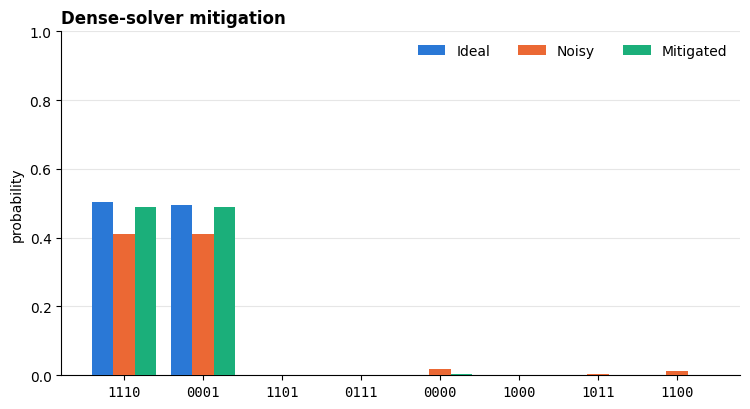

In [5]:
ent = QuantumCircuit(4)
ent.h(0)
ent.cx(0, 1)
ent.cx(1, 2)
ent.cx(2, 3)
ent.x(0)
ent.measure_all()

ent_ideal = ideal_probs(ent)
dense_out = mitigate_readout_errors(ent, noisy_backend, shots=SHOTS, local=False, matrix_format="dense")
sparse_out = mitigate_readout_errors(ent, noisy_backend, shots=SHOTS, local=False, matrix_format="sparse")

report(ent_ideal, dense_out, "dense solver")
report(ent_ideal, sparse_out, "sparse solver")
print(f"\ndense vs sparse agreement: {hellinger_fidelity(dense_out['mitigated'], sparse_out['mitigated']):.4f}")
plot_comparison(ent_ideal, dense_out, "Dense-solver mitigation")

## Summary

Across all examples the mitigated distribution is closer to the ideal than the
raw noisy one. The mitigator works for full and partial measurement, for local
and global calibration, and for both the dense and sparse solvers

In [6]:
from dotenv import load_dotenv
from haiqu.sdk import haiqu

from haiqu_rem import mitigate_readout_errors_haiqu

load_dotenv()

print(haiqu.login(raise_on_error=True))

print(
    haiqu.init(
        "Readout mitigation benchmark",
        experiment_description="Sparse REM compared with Haiqu readout mitigation",
        log_source_code=False,
    )
)

Success: Welcome to the Quantum World, barchyshynyura@gmail.com!
Set current experiment to: Readout mitigation benchmark. View on Dashboard: https://dashboard.haiqu.ai/experiment/exp-44b67628-c171-49a9-8a89-6a951fefc1a2


In [7]:
from qiskit_aer.noise import NoiseModel

haiqu_noise_model = NoiseModel.from_backend(FakeManilaV2())

haiqu_ghz_out = mitigate_readout_errors_haiqu(
    circuit=ghz,
    shots=1_000,
    device_id="aer_simulator",
    noise_model=haiqu_noise_model,
    include_raw=True,
    job_name="ghz-smoke-test",
)

Haiqu: GHZ smoke test
  measured physical qubits: [0, 1, 2, 3]
  Hellinger fidelity  noisy=0.8299  mitigated=0.9773  (improvement +0.1474)


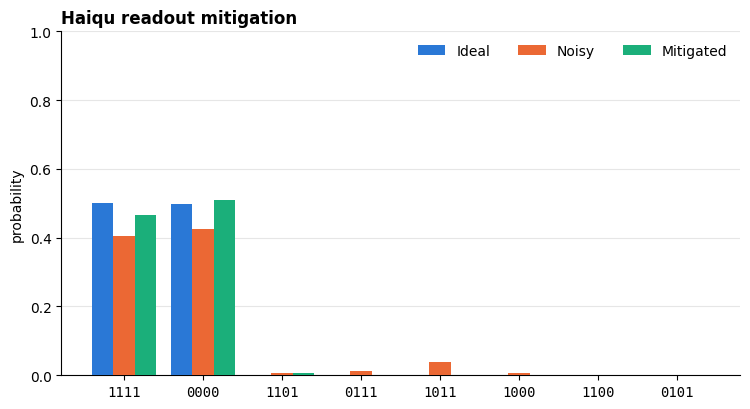

{'raw': {'wall_seconds': 7.4316202999998495,
  'cpu_seconds': 2.640625,
  'baseline_rss_mib': 340.72265625,
  'peak_rss_mib': 353.76953125,
  'peak_rss_delta_mib': 13.046875},
 'mitigated': {'wall_seconds': 12.282304100001056,
  'cpu_seconds': 3.640625,
  'baseline_rss_mib': 353.83984375,
  'peak_rss_mib': 361.03125,
  'peak_rss_delta_mib': 7.19140625}}

In [8]:
report(
    ghz_ideal,
    haiqu_ghz_out,
    "Haiqu: GHZ smoke test",
)

plot_comparison(
    ghz_ideal,
    haiqu_ghz_out,
    "Haiqu readout mitigation",
)

haiqu_ghz_out["metrics"]

In [9]:
import importlib
import haiqu_rem

importlib.reload(haiqu_rem)

from haiqu_rem import mitigate_readout_errors_haiqu

In [10]:
import inspect

print(inspect.signature(mitigate_readout_errors_haiqu))

(circuit: 'Any', shots: 'int' = 10000, device_id: 'str' = 'aer_simulator', noise_model: 'Any | None' = None, device_options: 'Mapping[str, Any] | None' = None, include_raw: 'bool' = True, job_name: 'str' = 'readout-mitigation', sample_interval_s: 'float' = 0.01) -> 'dict[str, Any]'
